<a href="https://colab.research.google.com/github/potgieterphiline/MBDS/blob/main/MIT801_SL_Q2_Exam_Philine_Potgieter_u27043275.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, confusion_matrix

#Question 2a)

In [60]:
test_data = pd.read_excel('/content/sample_data/Modtest.xlsx')
train_data = pd.read_excel('/content/sample_data/Modtrain.xlsx')

In [61]:
X_train = train_data[['x1', 'x2']]
y_train = train_data['gr']

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [62]:
print("LDA Coefficients (coef_):")
print(lda.coef_)
print("\nLDA Intercept (intercept_):")
print(lda.intercept_)
print("\nLDA Class Means (means_):")
print(lda.means_)
print("\nLDA Class Priors (priors_):")
print(lda.priors_)
print("\nLDA Scalings (scalings_):")
print(lda.scalings_)

LDA Coefficients (coef_):
[[-0.05217434 -0.33155358]
 [ 0.31278942 -0.32076985]
 [-0.23594963  0.47578466]]

LDA Intercept (intercept_):
[ 38.68535439  -0.28526011 -30.61127112]

LDA Class Means (means_):
[[ 99.85820979 100.04971329]
 [109.53187097 104.64072208]
 [104.57150743 119.38757325]]

LDA Class Priors (priors_):
[0.24655172 0.34741379 0.40603448]

LDA Scalings (scalings_):
[[-0.10809649 -0.18994155]
 [ 0.21625173 -0.01174714]]


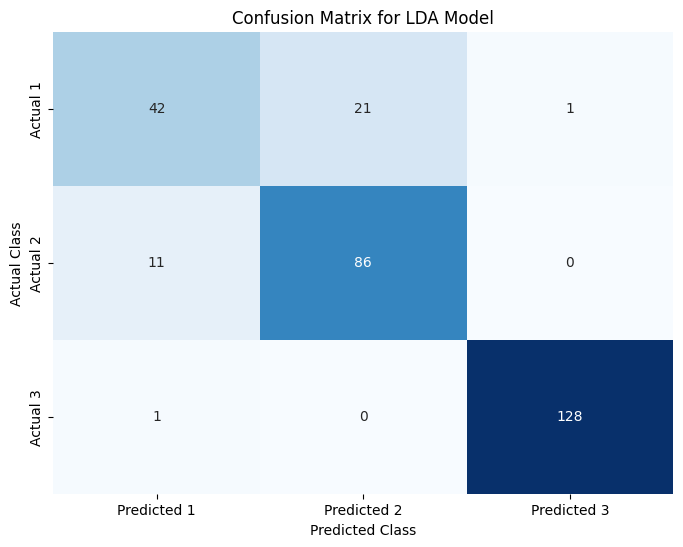


Overall Accuracy: 0.8828

Per-Class Metrics:


,Class,Sensitivity,Specificity
0,1,0.656250,0.946903
1,2,0.886598,0.891192
2,3,0.992248,0.993789


In [63]:
X_test = test_data[['x1', 'x2']]
y_test = test_data['gr']

# Make predictions on the test data
y_pred = lda.predict(X_test)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 1', 'Predicted 2', 'Predicted 3'],
            yticklabels=['Actual 1', 'Actual 2', 'Actual 3'])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix for LDA Model')
plt.show()

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy: {accuracy:.4f}")

# Calculate Sensitivity and Specificity for each class
num_classes = conf_matrix.shape[0]
class_metrics = []

for i in range(num_classes):
    TP = conf_matrix[i, i]
    FN = np.sum(conf_matrix[i, :]) - TP
    FP = np.sum(conf_matrix[:, i]) - TP
    TN = np.sum(conf_matrix) - (TP + FN + FP)

    sens = TP / (TP + FN) if (TP + FN) != 0 else 0
    spec = TN / (TN + FP) if (TN + FP) != 0 else 0

    class_metrics.append({
        'Class': i + 1,
        'Sensitivity': sens,
        'Specificity': spec
    })


class_metrics_df = pd.DataFrame(class_metrics)

print("\nPer-Class Metrics:")
display(class_metrics_df)

#Question 2c)

In [64]:
# Combine datasets
combined_data = pd.concat([train_data.drop(columns=['gr']), test_data.drop(columns=['gr'])], ignore_index=True)

print("Combined Data (first 5 rows):")
display(combined_data.head())

Combined Data (first 5 rows):


,x1,x2,obs id,Obs id
0,90.535,102.132,1.0,NaN
1,96.539,101.255,2.0,NaN
2,102.514,93.208,3.0,NaN
3,104.786,105.752,4.0,NaN
4,95.393,100.954,5.0,NaN


In [65]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(combined_data[['x1', 'x2']])

centroids = kmeans.cluster_centers_

print("\nEstimated Centroids of the 2-component K-Means Model:")
print(centroids)


Estimated Centroids of the 2-component K-Means Model:
[[104.53379022 101.62678121]
 [105.90134175 118.90341902]]


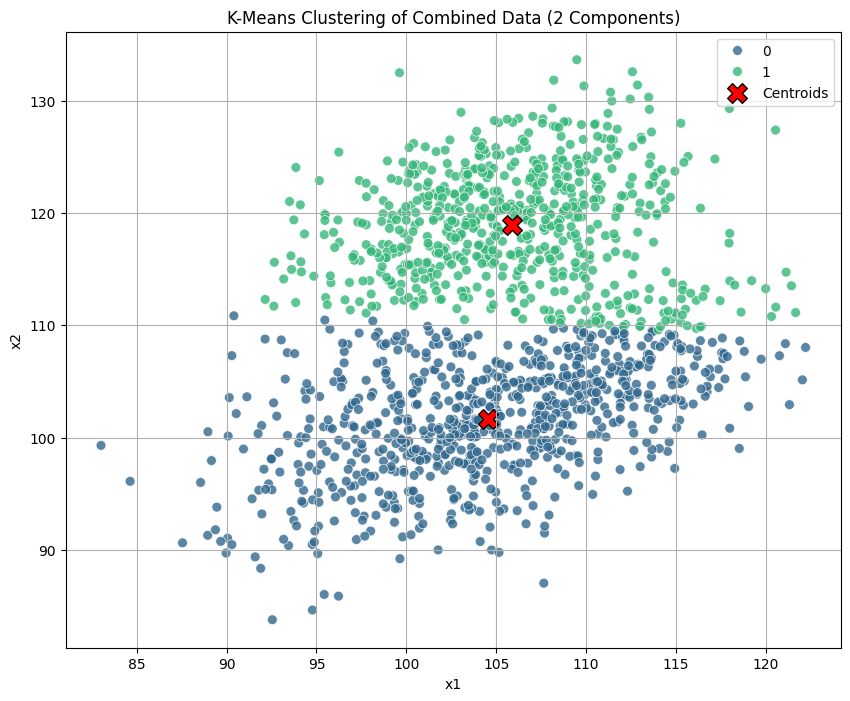

In [66]:
# Get cluster assignments
cluster_labels = kmeans.labels_

# Add cluster labels
combined_data['kmeans_cluster'] = cluster_labels


plt.figure(figsize=(10, 8))
sns.scatterplot(x='x1', y='x2', hue='kmeans_cluster', data=combined_data, palette='viridis', s=50, alpha=0.8)

plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='red', label='Centroids', edgecolor='black')

plt.title('K-Means Clustering of Combined Data (2 Components)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

In [67]:
X_gmm = combined_data[['x1', 'x2']]

initial_means = centroids

initial_covariances = []
initial_weights = []

for i in range(kmeans.n_clusters):
    cluster_data = combined_data[combined_data['kmeans_cluster'] == i][['x1', 'x2']]
    initial_covariances.append(np.cov(cluster_data.T))
    initial_weights.append(len(cluster_data) / len(combined_data))

initial_weights = np.array(initial_weights)

print("--- GMM Initial Parameters (from K-Means) ---")
print("Initial Means:\n", initial_means)
print("Initial Covariances (per component):\n", initial_covariances)
print("Initial Mixing Proportions (Weights):\n", initial_weights)

# Fit a 2-component GMM with initial values ---

gmm = GaussianMixture(n_components=2, random_state=42,
                      means_init=initial_means,
                      weights_init=initial_weights,
                      precisions_init=np.array([np.linalg.inv(cov) for cov in initial_covariances]), # GMM expects precisions_init
                      covariance_type='full') # K-Means covariances are 'full'
gmm.fit(X_gmm)

# --- Estimated Values from Fitted GMM ---
print("\n--- Estimated GMM Parameters ---")
print("Estimated Means:\n", gmm.means_)
print("Estimated Covariances (per component):\n", gmm.covariances_)
print("Estimated Mixing Proportions (Weights):\n", gmm.weights_)

# --- Calculate and Report Information Criteria ---

aic = gmm.aic(X_gmm)
bic = gmm.bic(X_gmm)

print(f"\nInformation Criteria for the GMM model:")
print(f"AIC: {aic:.2f}")
print(f"BIC: {bic:.2f}")

--- GMM Initial Parameters (from K-Means) ---
Initial Means:
 [[104.53379022 101.62678121]
 [105.90134175 118.90341902]]
Initial Covariances (per component):
 [array([[47.09206865, 15.13602133],
       [15.13602133, 24.74471051]]), array([[31.17737744,  0.6237214 ],
       [ 0.6237214 , 25.06749167]])]
Initial Mixing Proportions (Weights):
 [0.53586207 0.46413793]

--- Estimated GMM Parameters ---
Estimated Means:
 [[105.60170904 102.50521494]
 [104.57517466 119.42581747]]
Estimated Covariances (per component):
 [[[49.54647321 23.44136164]
  [23.44136164 32.35687221]]

 [[26.59118504 11.73740436]
  [11.73740436 25.02412693]]]
Estimated Mixing Proportions (Weights):
 [0.57801094 0.42198906]

Information Criteria for the GMM model:
AIC: 19694.23
BIC: 19752.30


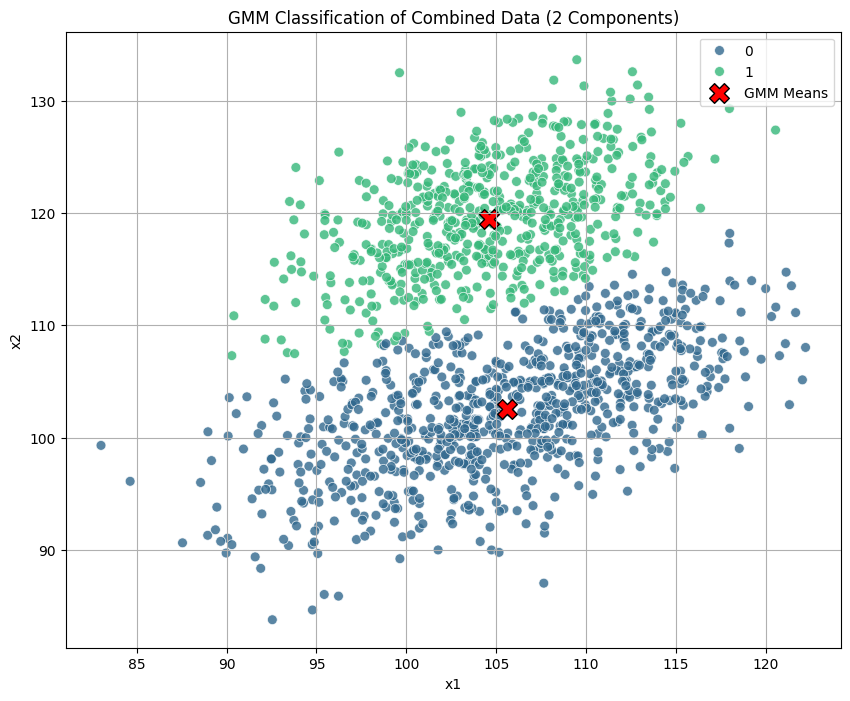

In [68]:
# Predict the cluster assignments
gmm_cluster_labels = gmm.predict(X_gmm)

# Add the GMM cluster labels
combined_data['gmm_cluster'] = gmm_cluster_labels

# Plot the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='x1', y='x2', hue='gmm_cluster', data=combined_data, palette='viridis', s=50, alpha=0.8)

plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], marker='X', s=200, color='red', label='GMM Means', edgecolor='black')

plt.title('GMM Classification of Combined Data (2 Components)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

#Question 2d)


--- K-Means Clustering with 3 Components ---
Estimated Centroids of the 3-component K-Means Model:
[[110.84115991 105.89984459]
 [104.89866496 120.00478291]
 [ 99.56095962  99.20114252]]


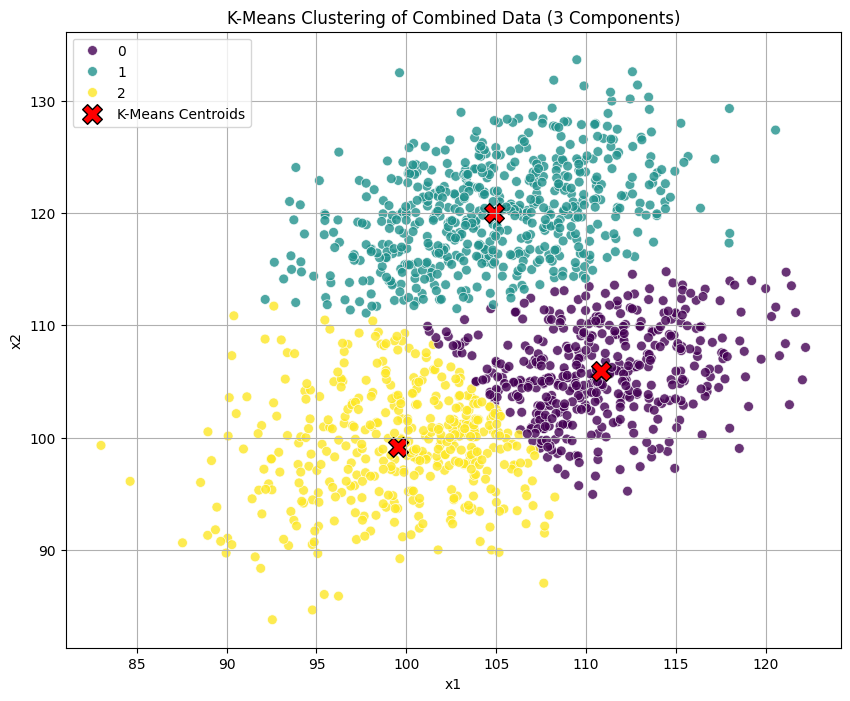

In [69]:
# K-Means Clustering with 3 Components
print("\n--- K-Means Clustering with 3 Components ---")

kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_3.fit(combined_data[['x1', 'x2']])
centroids_3 = kmeans_3.cluster_centers_

print("Estimated Centroids of the 3-component K-Means Model:")
print(centroids_3)

# Get cluster assignments
cluster_labels_3 = kmeans_3.labels_

# Add cluster labels
combined_data['kmeans_cluster_3'] = cluster_labels_3

# Plot the scatter plot for K-Means
plt.figure(figsize=(10, 8))
sns.scatterplot(x='x1', y='x2', hue='kmeans_cluster_3', data=combined_data, palette='viridis', s=50, alpha=0.8)

# Plot the centroids
plt.scatter(centroids_3[:, 0], centroids_3[:, 1], marker='X', s=200, color='red', label='K-Means Centroids', edgecolor='black')

plt.title('K-Means Clustering of Combined Data (3 Components)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()



--- GMM Initial Parameters (from 3-Component K-Means) ---
Initial Means:
 [[110.84115991 105.89984459]
 [104.89866496 120.00478291]
 [ 99.56095962  99.20114252]]
Initial Covariances (per component):
 [array([[16.62423357,  3.27241703],
       [ 3.27241703, 16.41078996]]), array([[25.13079353,  8.96832093],
       [ 8.96832093, 19.29082063]]), array([[20.38081638,  0.97771893],
       [ 0.97771893, 24.33710041]])]
Initial Mixing Proportions (Weights):
 [0.3062069  0.40344828 0.29034483]

--- Estimated GMM Parameters (3 Components) ---
Estimated Means:
 [[110.47320646 105.49281764]
 [104.67084453 119.65319308]
 [100.37610142  99.60399289]]
Estimated Covariances (per component):
 [[[21.16871005  8.66392342]
  [ 8.66392342 20.75648444]]

 [[25.80911924 10.77918624]
  [10.77918624 22.97560635]]

 [[27.77160298  6.96509322]
  [ 6.96509322 27.21567383]]]
Estimated Mixing Proportions (Weights):
 [0.29895031 0.41303719 0.2880125 ]

Information Criteria for the 3-Component GMM model:
AIC: 19675.

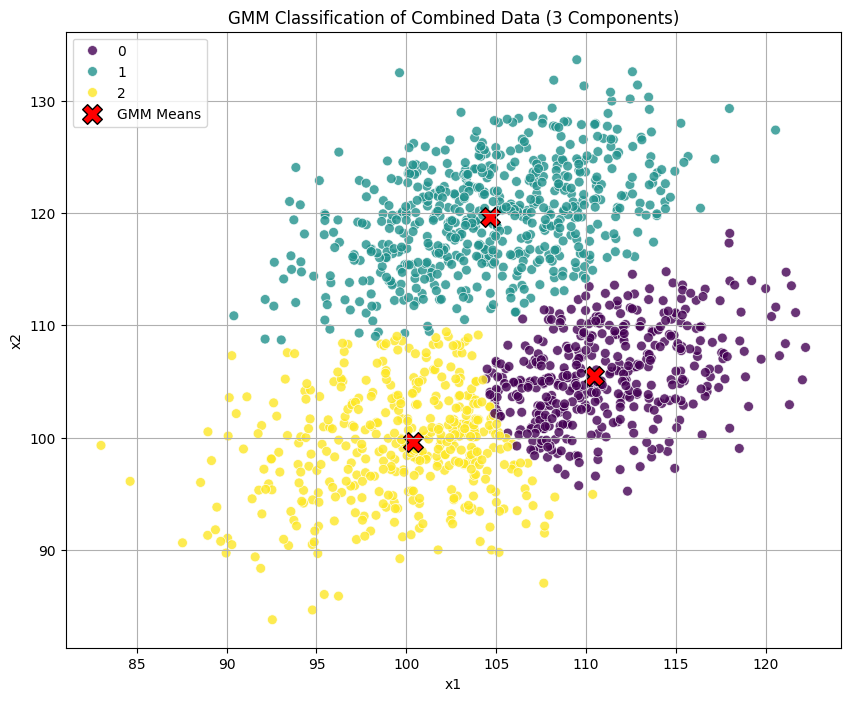

In [70]:
#Gaussian Mixture Model (GMM) with 3 Components, initialized by K-Means

# Prepare the data for GMM (features only)
X_gmm_3 = combined_data[['x1', 'x2']]

initial_means_3 = centroids_3
initial_covariances_3 = []
initial_weights_3 = []

for i in range(kmeans_3.n_clusters):
    cluster_data_3 = combined_data[combined_data['kmeans_cluster_3'] == i][['x1', 'x2']]
    initial_covariances_3.append(np.cov(cluster_data_3.T))
    initial_weights_3.append(len(cluster_data_3) / len(combined_data))

initial_weights_3 = np.array(initial_weights_3)

print("--- GMM Initial Parameters (from 3-Component K-Means) ---")
print("Initial Means:\n", initial_means_3)
print("Initial Covariances (per component):\n", initial_covariances_3)
print("Initial Mixing Proportions (Weights):\n", initial_weights_3)

# --- Fit a 3-component GMM with initial values ---

gmm_3 = GaussianMixture(n_components=3, random_state=42,
                      means_init=initial_means_3,
                      weights_init=initial_weights_3,
                      precisions_init=np.array([np.linalg.inv(cov) for cov in initial_covariances_3]),
                      covariance_type='full')
gmm_3.fit(X_gmm_3)

# --- Estimated Values from Fitted GMM ---
print("\n--- Estimated GMM Parameters (3 Components) ---")
print("Estimated Means:\n", gmm_3.means_)
print("Estimated Covariances (per component):\n", gmm_3.covariances_)
print("Estimated Mixing Proportions (Weights):\n", gmm_3.weights_)

# --- Calculate and Report Information Criteria ---

aic_3 = gmm_3.aic(X_gmm_3)
bic_3 = gmm_3.bic(X_gmm_3)

print(f"\nInformation Criteria for the 3-Component GMM model:")
print(f"AIC: {aic_3:.2f}")
print(f"BIC: {bic_3:.2f}")

#Graphical Presentation
print("\n--- GMM Classification Graphical Presentation (3 Components) ---")

# Predict the cluster assignments
gmm_cluster_labels_3 = gmm_3.predict(X_gmm_3)

# plot
combined_data['gmm_cluster_3'] = gmm_cluster_labels_3

# catter plot=
plt.figure(figsize=(10, 8))
sns.scatterplot(x='x1', y='x2', hue='gmm_cluster_3', data=combined_data, palette='viridis', s=50, alpha=0.8)

# Plot  GMM means
plt.scatter(gmm_3.means_[:, 0], gmm_3.means_[:, 1], marker='X', s=200, color='red', label='GMM Means', edgecolor='black')

plt.title('GMM Classification of Combined Data (3 Components)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

[[111.26710817 105.89660337]
 [107.8834491  122.48176946]
 [ 99.88855721  98.53314925]
 [100.7347953  115.48250336]]


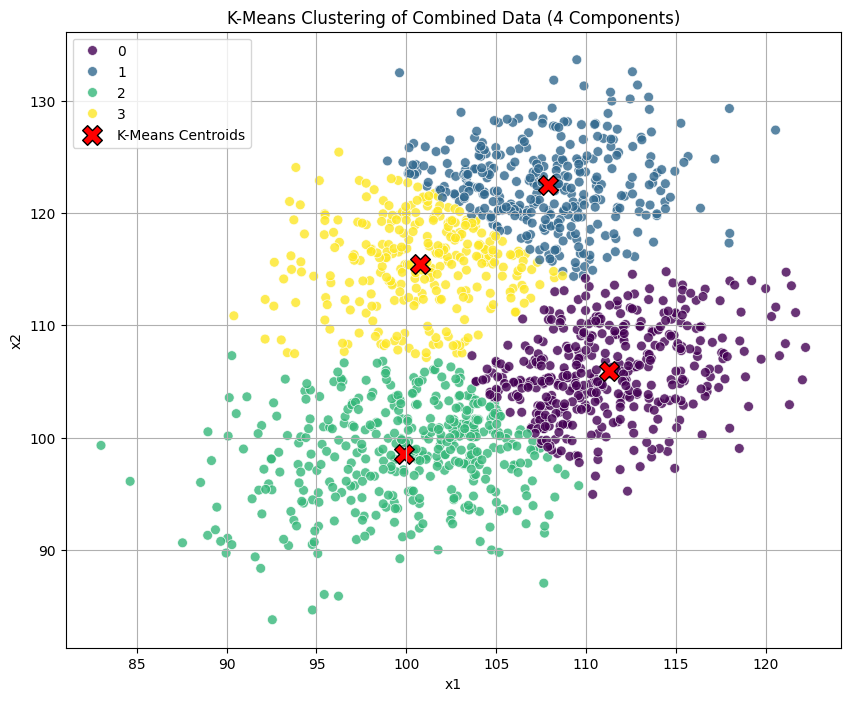

--- GMM Initial Parameters (from 4-Component K-Means) ---
Initial Means:
 [[111.26710817 105.89660337]
 [107.8834491  122.48176946]
 [ 99.88855721  98.53314925]
 [100.7347953  115.48250336]]
Initial Covariances (per component):
 [array([[14.51194772,  4.22581654],
       [ 4.22581654, 15.82007522]]), array([[14.59855177, -0.64697192],
       [-0.64697192, 13.29141847]]), array([[21.73239671,  2.67931567],
       [ 2.67931567, 18.73852939]]), array([[12.0254585 ,  0.23418222],
       [ 0.23418222, 15.19019961]])]
Initial Mixing Proportions (Weights):
 [0.28689655 0.23034483 0.27724138 0.20551724]

--- Estimated GMM Parameters (4 Components) ---
Estimated Means:
 [[110.62557872 105.64057582]
 [107.35470365 121.65536741]
 [100.62925966  99.46689507]
 [101.21293792 116.77769265]]
Estimated Covariances (per component):
 [[[20.68303538  8.25898424]
  [ 8.25898424 19.93650981]]

 [[17.26191765  3.74570454]
  [ 3.74570454 17.53300075]]

 [[29.29458075  7.34906252]
  [ 7.34906252 25.474725  ]]


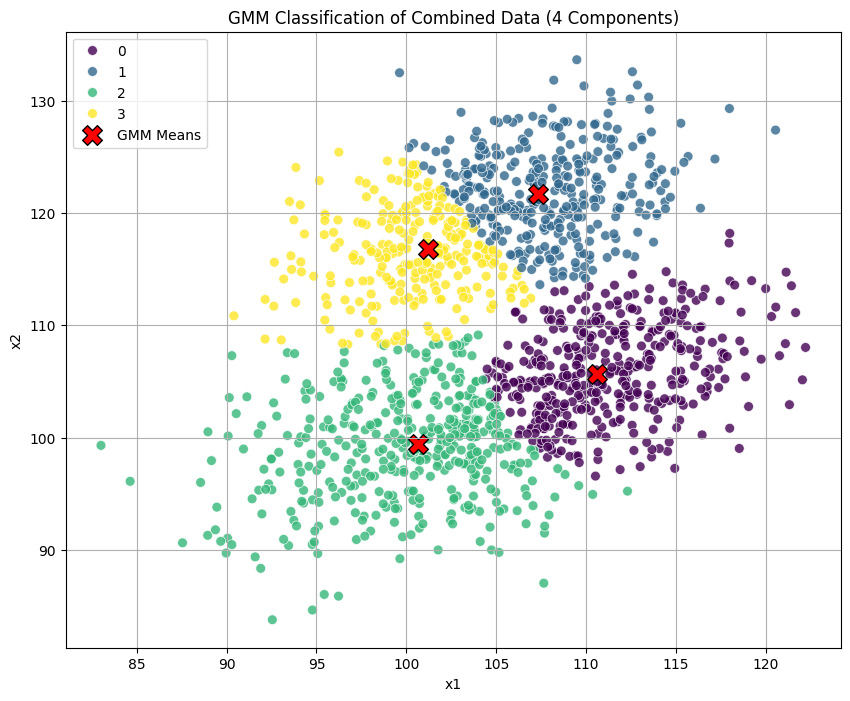

In [71]:
# K-Means Clustering with 4 Components

kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_4.fit(combined_data[['x1', 'x2']])
centroids_4 = kmeans_4.cluster_centers_

print(centroids_4)

# Get cluster assignments
cluster_labels_4 = kmeans_4.labels_

# Add cluster labels
combined_data['kmeans_cluster_4'] = cluster_labels_4

# scatter plot for K-Means
plt.figure(figsize=(10, 8))
sns.scatterplot(x='x1', y='x2', hue='kmeans_cluster_4', data=combined_data, palette='viridis', s=50, alpha=0.8)

# Plot the centroids
plt.scatter(centroids_4[:, 0], centroids_4[:, 1], marker='X', s=200, color='red', label='K-Means Centroids', edgecolor='black')

plt.title('K-Means Clustering of Combined Data (4 Components)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

# GMM

X_gmm_4 = combined_data[['x1', 'x2']]

initial_means_4 = centroids_4

initial_covariances_4 = []
initial_weights_4 = []

for i in range(kmeans_4.n_clusters):
    cluster_data_4 = combined_data[combined_data['kmeans_cluster_4'] == i][['x1', 'x2']]
    initial_covariances_4.append(np.cov(cluster_data_4.T))
    initial_weights_4.append(len(cluster_data_4) / len(combined_data))

initial_weights_4 = np.array(initial_weights_4)

print("--- GMM Initial Parameters (from 4-Component K-Means) ---")
print("Initial Means:\n", initial_means_4)
print("Initial Covariances (per component):\n", initial_covariances_4)
print("Initial Mixing Proportions (Weights):\n", initial_weights_4)

# --- Fit a 4-component GMM with initial values ---

gmm_4 = GaussianMixture(n_components=4, random_state=42,
                      means_init=initial_means_4,
                      weights_init=initial_weights_4,
                      precisions_init=np.array([np.linalg.inv(cov) for cov in initial_covariances_4]),
                      covariance_type='full')
gmm_4.fit(X_gmm_4)

# --- Estimated Values from Fitted GMM ---
print("\n--- Estimated GMM Parameters (4 Components) ---")
print("Estimated Means:\n", gmm_4.means_)
print("Estimated Covariances (per component):\n", gmm_4.covariances_)
print("Estimated Mixing Proportions (Weights):\n", gmm_4.weights_)

# --- Calculate and Report Information Criteria ---

aic_4 = gmm_4.aic(X_gmm_4)
bic_4 = gmm_4.bic(X_gmm_4)

print(f"\nInformation Criteria for the 4-Component GMM model:")
print(f"AIC: {aic_4:.2f}")
print(f"BIC: {bic_4:.2f}")

# Graphical Presentation
print("\n--- GMM Classification Graphical Presentation (4 Components) ---")

# Predict the cluster assignments
gmm_cluster_labels_4 = gmm_4.predict(X_gmm_4)

# plotting
combined_data['gmm_cluster_4'] = gmm_cluster_labels_4

# scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='x1', y='x2', hue='gmm_cluster_4', data=combined_data, palette='viridis', s=50, alpha=0.8)

# Plot the estimated GMM means (centroids)
plt.scatter(gmm_4.means_[:, 0], gmm_4.means_[:, 1], marker='X', s=200, color='red', label='GMM Means', edgecolor='black')

plt.title('GMM Classification of Combined Data (4 Components)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

In [72]:
true_labels_combined = pd.concat([train_data['gr'], test_data['gr']], ignore_index=True)
X_gmm_combined = combined_data[['x1', 'x2']]

def calculate_per_class_metrics_with_labels(conf_matrix, class_labels):
    metrics = {'Sensitivity': {}, 'Specificity': {}}
    for i, class_label in enumerate(class_labels):
        TP = conf_matrix[i, i]
        FN = np.sum(conf_matrix[i, :]) - TP
        FP = np.sum(conf_matrix[:, i]) - TP
        TN = np.sum(conf_matrix) - (TP + FN + FP)

        sens = TP / (TP + FN) if (TP + FN) != 0 else 0
        spec = TN / (TN + FP) if (TN + FP) != 0 else 0
        metrics['Sensitivity'][f'Sensitivity_Class {class_label}'] = sens
        metrics['Specificity'][f'Specificity_Class {class_label}'] = spec
    return metrics

def get_gmm_classification_metrics(gmm_model, X_data, true_labels):
    gmm_predicted_clusters = gmm_model.predict(X_data)

    cluster_to_class_map = {}
    temp_df = pd.DataFrame({'cluster': gmm_predicted_clusters, 'true_gr': true_labels})

    all_true_classes = sorted(true_labels.unique())

    for cluster_id in np.unique(gmm_predicted_clusters):
        true_labels_in_cluster = temp_df[temp_df['cluster'] == cluster_id]['true_gr']
        if not true_labels_in_cluster.empty:
            majority_label = true_labels_in_cluster.mode()[0]
            cluster_to_class_map[cluster_id] = majority_label
        else:
            cluster_to_class_map[cluster_id] = true_labels.mode()[0]

    gmm_assigned_labels = np.array([cluster_to_class_map[c_id] for c_id in gmm_predicted_clusters])

    accuracy = accuracy_score(true_labels, gmm_assigned_labels)
    conf_matrix = confusion_matrix(true_labels, gmm_assigned_labels, labels=all_true_classes)

    per_class_metrics = calculate_per_class_metrics_with_labels(conf_matrix, all_true_classes)

    return accuracy, per_class_metrics['Sensitivity'], per_class_metrics['Specificity']


comparison_data = {}


acc_2, sens_2, spec_2 = get_gmm_classification_metrics(gmm, X_gmm_combined, true_labels_combined)
comparison_data['2-Component GMM'] = {
    'AIC': aic,
    'BIC': bic,
    'Overall Accuracy': acc_2,
    **sens_2,
    **spec_2
}


acc_3, sens_3, spec_3 = get_gmm_classification_metrics(gmm_3, X_gmm_combined, true_labels_combined)
comparison_data['3-Component GMM'] = {
    'AIC': aic_3,
    'BIC': bic_3,
    'Overall Accuracy': acc_3,
    **sens_3,
    **spec_3
}


acc_4, sens_4, spec_4 = get_gmm_classification_metrics(gmm_4, X_gmm_combined, true_labels_combined)
comparison_data['4-Component GMM'] = {
    'AIC': aic_4,
    'BIC': bic_4,
    'Overall Accuracy': acc_4,
    **sens_4,
    **spec_4
}


df_comparison = pd.DataFrame(comparison_data)


print("\n--- Comparison of GMM Models (2, 3, and 4 Components) ---")
print("\nEstimated Centroids:")
print("2-Component GMM:\n", gmm.means_.round(2))
print("3-Component GMM:\n", gmm_3.means_.round(2))
print("4-Component GMM:\n", gmm_4.means_.round(2))

print("\nInformation Criteria and Overall Accuracy:")
display(df_comparison.loc[['AIC', 'BIC', 'Overall Accuracy']].round(4).T)

print("\nSensitivity by Class:")
df_sensitivity = df_comparison.filter(like='Sensitivity_Class', axis=0).round(4).T
display(df_sensitivity)

print("\nSpecificity by Class:")
df_specificity = df_comparison.filter(like='Specificity_Class', axis=0).round(4).T
display(df_specificity)


--- Comparison of GMM Models (2, 3, and 4 Components) ---

Estimated Centroids:
2-Component GMM:
 [[105.6  102.51]
 [104.58 119.43]]
3-Component GMM:
 [[110.47 105.49]
 [104.67 119.65]
 [100.38  99.6 ]]
4-Component GMM:
 [[110.63 105.64]
 [107.35 121.66]
 [100.63  99.47]
 [101.21 116.78]]

Information Criteria and Overall Accuracy:


,AIC,BIC,Overall Accuracy
2-Component GMM,19694.2276,19752.3001,0.7400
3-Component GMM,19675.3493,19765.0977,0.8545
4-Component GMM,19687.3218,19808.7462,0.8503



Sensitivity by Class:


,Sensitivity_Class 1,Sensitivity_Class 2,Sensitivity_Class 3
2-Component GMM,0.00,0.972,0.9783
3-Component GMM,0.82,0.738,0.9717
4-Component GMM,0.82,0.718,0.9783



Specificity by Class:


,Specificity_Class 1,Specificity_Class 2,Specificity_Class 3
2-Component GMM,1.0000,0.6284,0.9718
3-Component GMM,0.8827,0.9358,0.9753
4-Component GMM,0.8764,0.9389,0.9729


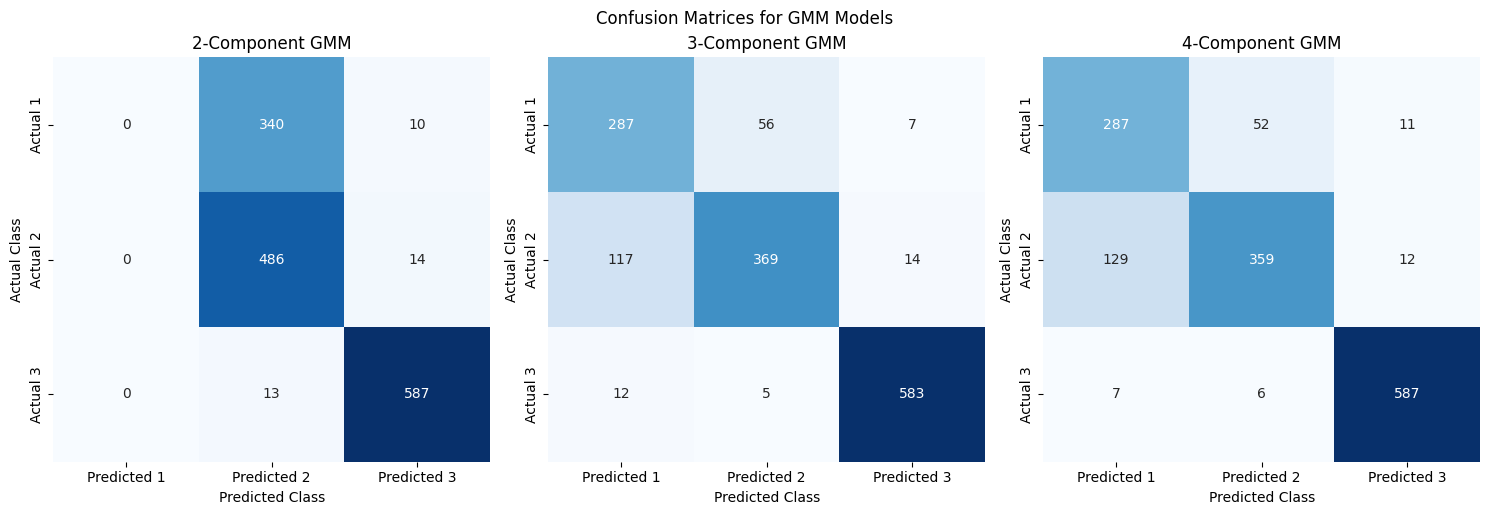

In [73]:
def map_gmm_clusters_to_true_labels(gmm_model, X_data, true_labels):
    gmm_predicted_clusters = gmm_model.predict(X_data)

    cluster_to_class_map = {}
    temp_df = pd.DataFrame({'cluster': gmm_predicted_clusters, 'true_gr': true_labels})

    for cluster_id in np.unique(gmm_predicted_clusters):
        true_labels_in_cluster = temp_df[temp_df['cluster'] == cluster_id]['true_gr']
        if not true_labels_in_cluster.empty:
            majority_label = true_labels_in_cluster.mode()[0]
            cluster_to_class_map[cluster_id] = majority_label
        else:

            cluster_to_class_map[cluster_id] = true_labels.mode()[0]

    gmm_assigned_labels = np.array([cluster_to_class_map[c_id] for c_id in gmm_predicted_clusters])
    return gmm_assigned_labels


all_true_classes = sorted(true_labels_combined.unique())


gmm_assigned_labels_2 = map_gmm_clusters_to_true_labels(gmm, X_gmm_combined, true_labels_combined)
conf_matrix_2 = confusion_matrix(true_labels_combined, gmm_assigned_labels_2, labels=all_true_classes)

gmm_assigned_labels_3 = map_gmm_clusters_to_true_labels(gmm_3, X_gmm_combined, true_labels_combined)
conf_matrix_3 = confusion_matrix(true_labels_combined, gmm_assigned_labels_3, labels=all_true_classes)

gmm_assigned_labels_4 = map_gmm_clusters_to_true_labels(gmm_4, X_gmm_combined, true_labels_combined)
conf_matrix_4 = confusion_matrix(true_labels_combined, gmm_assigned_labels_4, labels=all_true_classes)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.heatmap(conf_matrix_2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f'Predicted {c}' for c in all_true_classes],
            yticklabels=[f'Actual {c}' for c in all_true_classes],
            ax=axes[0])
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('Actual Class')
axes[0].set_title('2-Component GMM')

sns.heatmap(conf_matrix_3, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f'Predicted {c}' for c in all_true_classes],
            yticklabels=[f'Actual {c}' for c in all_true_classes],
            ax=axes[1])
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('Actual Class')
axes[1].set_title('3-Component GMM')

sns.heatmap(conf_matrix_4, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f'Predicted {c}' for c in all_true_classes],
            yticklabels=[f'Actual {c}' for c in all_true_classes],
            ax=axes[2])
axes[2].set_xlabel('Predicted Class')
axes[2].set_ylabel('Actual Class')
axes[2].set_title('4-Component GMM')

plt.tight_layout()
plt.suptitle('Confusion Matrices for GMM Models', y=1.02)
plt.show()



--- Analysis of 3-Component GMM Classification ---

Overall Accuracy (3-Component GMM mapped to true labels): 0.8545

Sensitivity by Class (3-Component GMM):
Sensitivity_Class 1: 0.8200
Sensitivity_Class 2: 0.7380
Sensitivity_Class 3: 0.9717

Specificity by Class (3-Component GMM):
Specificity_Class 1: 0.8827
Specificity_Class 2: 0.9358
Specificity_Class 3: 0.9753


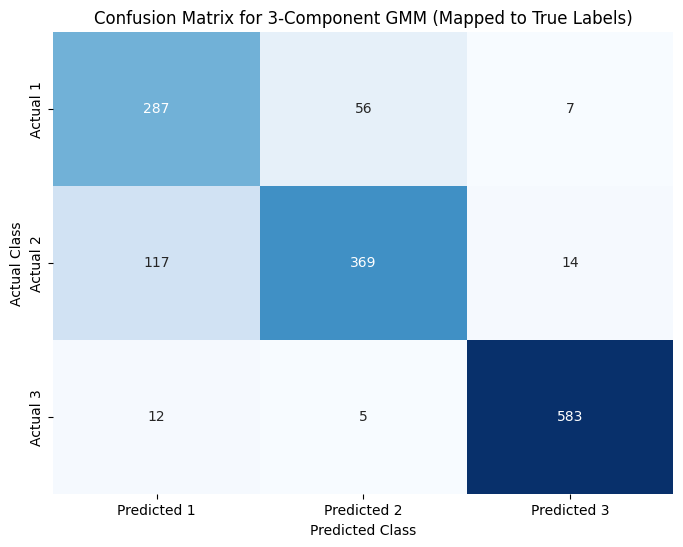

In [74]:

def calculate_per_class_metrics_with_labels(conf_matrix, class_labels):
    metrics = {'Sensitivity': {}, 'Specificity': {}}
    for i, class_label in enumerate(class_labels):
        TP = conf_matrix[i, i]
        FN = np.sum(conf_matrix[i, :]) - TP
        FP = np.sum(conf_matrix[:, i]) - TP
        TN = np.sum(conf_matrix) - (TP + FN + FP)

        sens = TP / (TP + FN) if (TP + FN) != 0 else 0
        spec = TN / (TN + FP) if (TN + FP) != 0 else 0
        metrics['Sensitivity'][f'Sensitivity_Class {class_label}'] = sens
        metrics['Specificity'][f'Specificity_Class {class_label}'] = spec
    return metrics


def map_gmm_clusters_to_true_labels(gmm_model, X_data, true_labels):
    gmm_predicted_clusters = gmm_model.predict(X_data)

    cluster_to_class_map = {}
    temp_df = pd.DataFrame({'cluster': gmm_predicted_clusters, 'true_gr': true_labels})

    for cluster_id in np.unique(gmm_predicted_clusters):
        true_labels_in_cluster = temp_df[temp_df['cluster'] == cluster_id]['true_gr']
        if not true_labels_in_cluster.empty:
            majority_label = true_labels_in_cluster.mode()[0]
            cluster_to_class_map[cluster_id] = majority_label
        else:
            cluster_to_class_map[cluster_id] = true_labels.mode()[0]

    gmm_assigned_labels = np.array([cluster_to_class_map[c_id] for c_id in gmm_predicted_clusters])
    return gmm_assigned_labels


def get_gmm_classification_metrics(gmm_model, X_data, true_labels):
    gmm_predicted_clusters = gmm_model.predict(X_data)

    cluster_to_class_map = {}
    temp_df = pd.DataFrame({'cluster': gmm_predicted_clusters, 'true_gr': true_labels})

    all_true_classes = sorted(true_labels.unique())

    for cluster_id in np.unique(gmm_predicted_clusters):
        true_labels_in_cluster = temp_df[temp_df['cluster'] == cluster_id]['true_gr']
        if not true_labels_in_cluster.empty:
            majority_label = true_labels_in_cluster.mode()[0]
            cluster_to_class_map[cluster_id] = majority_label
        else:
            cluster_to_class_map[cluster_id] = true_labels.mode()[0]

    gmm_assigned_labels = np.array([cluster_to_class_map[c_id] for c_id in gmm_predicted_clusters])

    accuracy = accuracy_score(true_labels, gmm_assigned_labels)
    conf_matrix = confusion_matrix(true_labels, gmm_assigned_labels, labels=all_true_classes)

    per_class_metrics = calculate_per_class_metrics_with_labels(conf_matrix, all_true_classes)

    return accuracy, per_class_metrics['Sensitivity'], per_class_metrics['Specificity'], conf_matrix

print("\n--- Analysis of 3-Component GMM Classification ---")

acc_3_final, sens_3_final, spec_3_final, conf_matrix_3_final = get_gmm_classification_metrics(gmm_3, X_gmm_combined, true_labels_combined)

print(f"\nOverall Accuracy (3-Component GMM mapped to true labels): {acc_3_final:.4f}")

print("\nSensitivity by Class (3-Component GMM):")
for k, v in sens_3_final.items():
    print(f"{k}: {v:.4f}")

print("\nSpecificity by Class (3-Component GMM):")
for k, v in spec_3_final.items():
    print(f"{k}: {v:.4f}")

all_true_classes = sorted(true_labels_combined.unique())
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_3_final, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f'Predicted {c}' for c in all_true_classes],
            yticklabels=[f'Actual {c}' for c in all_true_classes])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix for 3-Component GMM (Mapped to True Labels)')
plt.show()